In [165]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, classification_report


#### BRFSS 2021-2023

In [199]:
# get csv processed data
df_train = pd.read_csv(os.path.join('data', 'BRFSS', 'BRFSS_2021_2023.csv'))

# truncate the data to convert bmi> 40 to 40
df_train.loc[df_train['BMI'] > 40, 'BMI'] = 40

# select the columns to be used for training
df_train = df_train[['Gender', 'Age', 'BMI', 'Race', 'Education', 'Diabetes', 'Hypertension', 'Poverty_Level', 'Health_Insurance']]

In [200]:
# Group by Race and calculate the mean BMI for each race
print("Original BRFSS data 2021-2023")
print(f"{df_train['BMI'].mean():.4f} mean BMI")  # Corrected quotation marks
mean_bmi_per_race = df_train.groupby('Race')['BMI'].mean()

# Display the mean BMI per race
print("Mean BMI per Race:")
print(mean_bmi_per_race)


Original BRFSS data 2021-2023
28.1759 mean BMI
Mean BMI per Race:
Race
1.0    28.044843
2.0    29.528333
3.0    28.652974
4.0    25.093905
5.0    28.676051
Name: BMI, dtype: float64


In [201]:
df_train.shape

(89311, 9)

In [202]:
# correlation matrix
corr = df_train.corr()
print(corr['BMI'])

Gender             -0.020974
Age                -0.097123
BMI                 1.000000
Race                0.022878
Education          -0.054049
Diabetes           -0.244998
Hypertension       -0.200712
Poverty_Level      -0.055485
Health_Insurance    0.001801
Name: BMI, dtype: float64


In [203]:
df_train.head()

,Gender,Age,BMI,Race,Education,Diabetes,Hypertension,Poverty_Level,Health_Insurance
0,2.0,6.0,14.54,1.0,3.0,2.0,2.0,4.305396,1.0
1,2.0,6.0,28.29,2.0,3.0,1.0,1.0,1.722158,1.0
2,2.0,5.0,33.47,1.0,3.0,1.0,1.0,5.000000,1.0
3,1.0,6.0,24.37,1.0,4.0,2.0,2.0,5.000000,1.0
4,2.0,6.0,27.46,1.0,4.0,2.0,1.0,2.329193,1.0


In [204]:
categorical_features = ['Gender', 'Race', 'Hypertension', 'Diabetes', 'Education', 'Age', 'Health_Insurance']
target  = ['BMI']
train_data = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)

In [205]:
train_data.head()

,BMI,Poverty_Level,Gender_2.0,Race_2.0,Race_3.0,Race_4.0,Race_5.0,Hypertension_2.0,Diabetes_2.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Age_2.0,Age_3.0,Age_4.0,Age_5.0,Age_6.0,Health_Insurance_2.0
0,14.54,4.305396,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0
1,28.29,1.722158,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,33.47,5.000000,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,24.37,5.000000,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0
4,27.46,2.329193,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0


In [206]:
train_data = train_data.dropna()
train_data.shape

(89311, 19)

### Standard model 

In [288]:
# Define your neural network class
class neural_net(nn.Module):
    def __init__(self, input_size, model_class):
        super().__init__()
        if model_class == "neural_network":
            self.h_net = nn.Sequential(
                nn.Linear(input_size, 64),
                nn.ReLU(),
                nn.Linear(64, 64),
                nn.ReLU(),
                nn.Linear(64, 1),
            )
        elif model_class == "linear":
            self.h_net = nn.Sequential(nn.Linear(input_size, 1))

    def forward(self, x):
        return self.h_net(x)

# Prepare the data
X = train_data.drop(target, axis=1).values
y = train_data[target].values.squeeze()

# Split the data into X_train, X_val, y_train, y_val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Create a dataset and dataloader for batch training
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model, optimizer, and loss function
model = neural_net(X_train.shape[1], "neural_network").to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [289]:
X_train.shape

torch.Size([71448, 18])

In [290]:
# Training loop
epochs = 100
loss_arr = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        predictions = model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track the loss for each batch
        running_loss += loss.item()
    loss_arr.append(running_loss / len(train_loader))
    if (epoch+1) % 10 == 0:
        print(f"Loss: {loss.item():.4f}")
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")


Loss: 26.3931
Epoch 10/100, Loss: 28.4055
Loss: 29.1200
Epoch 20/100, Loss: 28.2716
Loss: 29.9146
Epoch 30/100, Loss: 28.2359
Loss: 32.0530
Epoch 40/100, Loss: 28.4386
Loss: 26.0673
Epoch 50/100, Loss: 28.2475
Loss: 28.1308
Epoch 60/100, Loss: 28.5784
Loss: 30.3195
Epoch 70/100, Loss: 28.3882
Loss: 28.1025
Epoch 80/100, Loss: 28.0313
Loss: 27.9466
Epoch 90/100, Loss: 28.0406
Loss: 28.2930
Epoch 100/100, Loss: 28.0368


In [291]:
with torch.no_grad():
    model.eval()
    y_pred = model(X_val.to(device)).squeeze().cpu().numpy()
    val_loss = criterion(torch.tensor(y_pred), y_val).item()
    # RMSE
    rmse = np.sqrt(np.mean((y_pred - y_val.numpy())**2))
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2_score(y_val.numpy(), y_pred):.4f}")

RMSE: 5.2708
R2 Score: 0.1139


In [293]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_val)
print(f"Linear Regression R2 Score: {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(np.mean((y_val - y_pred).cpu().numpy() ** 2)):.4f}")

Linear Regression R2 Score: 0.1194
RMSE: 5.2545


In [253]:
y_val.shape

torch.Size([17863])

### RU regression model

In [209]:
# define custom RU loss
def RU_loss(z, a, gamma, y):
    L = (z - y) ** 2
    return torch.mean(
        (L / gamma)
        + (1 - (1 / gamma)) * a
        + (gamma - (1 / gamma)) * torch.nn.functional.relu(L - a)
    )
    

# Hyperparameters
n_epochs = 100
gamma_values = [1.5, 2, 2.5, 3, 4, 5, 10]
batch_size = 1024

# Placeholder for storing loss values
LOSS = {}
h_net = {}
a_net = {}

input_size = X_train.shape[1]

# Train RU model for each gamma value
for gamma in gamma_values:
    print(f"Training with  \u0393 = {gamma}" + " " * 100)  # unicode character for Gamma

    # Initialize loss array for each gamma
    LOSS[gamma] = []

    # Define RU model's h function net and alpha function net
    h_net[gamma] = nn.Sequential(
        nn.Linear(input_size, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1)
    ).to(device)

    a_net[gamma] = nn.Sequential(
        nn.Linear(input_size, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1)
    ).to(device)

    # Define optimizer for RU model
    params = list(h_net[gamma].parameters()) + list(a_net[gamma].parameters())
    optimizer_ru = optim.Adam(params, lr=1e-2)

    # Training loop
    for epoch in range(n_epochs):
        epoch_loss = 0.0  # Track epoch loss for averaging
        num_batches = 0

        for Xbatch, ybatch in train_loader:
            # Forward pass for h and a networks
            Xbatch, ybatch = Xbatch.to(device), ybatch.to(device)
            h = h_net[gamma](Xbatch)
            a = a_net[gamma](Xbatch)

            # Compute RU loss
            ru_loss = RU_loss(h, a, gamma, ybatch)
            # ru_loss = Bayesian_RU_loss(h, a, gamma, ybatch, params, lambda_reg=0.001)

            # Backward propagation and optimizer step
            optimizer_ru.zero_grad()
            ru_loss.backward()
            optimizer_ru.step()

            # Track batch loss and update epoch loss
            epoch_loss += ru_loss.item()
            num_batches += 1

        # Calculate and store average epoch loss for visualization
        avg_epoch_loss = epoch_loss / len(train_loader)
        LOSS[gamma].append(avg_epoch_loss)

        # Print epoch progress
        if (epoch + 1) % 10 == 0:
            print(f"Gamma {gamma} | Epoch {epoch + 1}/{n_epochs} | Avg Loss: {avg_epoch_loss:.4f}")

print("Training completed for all gamma values.")



Training with  Γ = 1.5                                                                                                    
Gamma 1.5 | Epoch 10/100 | Avg Loss: 44.5484
Gamma 1.5 | Epoch 20/100 | Avg Loss: 44.4978
Gamma 1.5 | Epoch 30/100 | Avg Loss: 44.7496
Gamma 1.5 | Epoch 40/100 | Avg Loss: 44.9491
Gamma 1.5 | Epoch 50/100 | Avg Loss: 44.9680
Gamma 1.5 | Epoch 60/100 | Avg Loss: 44.3941
Gamma 1.5 | Epoch 70/100 | Avg Loss: 44.6010
Gamma 1.5 | Epoch 80/100 | Avg Loss: 44.5212
Gamma 1.5 | Epoch 90/100 | Avg Loss: 44.4644
Gamma 1.5 | Epoch 100/100 | Avg Loss: 44.6284
Training with  Γ = 2                                                                                                    
Gamma 2 | Epoch 10/100 | Avg Loss: 55.1447
Gamma 2 | Epoch 20/100 | Avg Loss: 55.0020
Gamma 2 | Epoch 30/100 | Avg Loss: 54.8688
Gamma 2 | Epoch 40/100 | Avg Loss: 54.9483
Gamma 2 | Epoch 50/100 | Avg Loss: 55.2413
Gamma 2 | Epoch 60/100 | Avg Loss: 54.7909
Gamma 2 | Epoch 70/100 | Avg Loss: 55.0441
Gamm

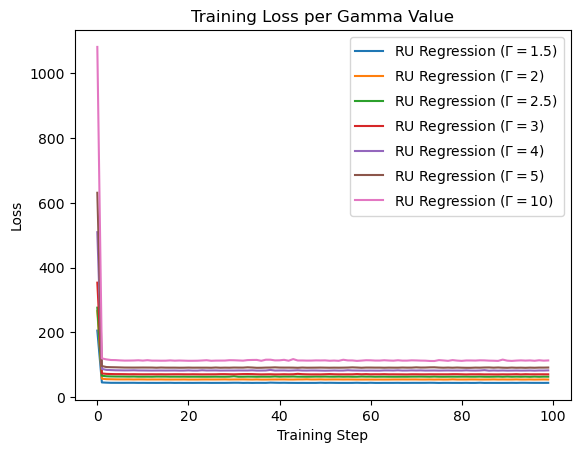

In [210]:

for gamma in gamma_values:
    plt.plot(
        [i for i in LOSS[gamma]],  # No need for `.cpu().numpy()`, as values are already floats
        label="RU Regression " + r"$(\Gamma=$" + f"{gamma})"
    )

# Add plot labels
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss per Gamma Value")
plt.show()


In [ ]:
# Evaluation on validation data
rmse = []
for gamma in gamma_values:
    h_net[gamma].eval()
    a_net[gamma].eval()
    with torch.no_grad():
        X_val, y_val = X_val.to(device), y_val.to(device)
        h = h_net[gamma](X_val)
        y_pred = h.cpu().numpy()
        print(f"Gamma: {gamma}")
        abs_error = np.abs(y_val.cpu().numpy() - y_pred)
        mse = np.mean((y_val.cpu().numpy() - y_pred) ** 2)
        print(f"Mean Absolute Error: {np.mean(abs_error):.4f}")
        print("RMSE: ", np.sqrt(mse))  
        print("Mean Prediction per Race:")
        rmse.append(np.sqrt(mse))
 

Gamma: 1.5
Mean Absolute Error: 4.4902
RMSE:  5.6041994
Mean Prediction per Race:
Gamma: 2
Mean Absolute Error: 4.5307
RMSE:  5.6025915
Mean Prediction per Race:
Gamma: 2.5
Mean Absolute Error: 4.5121
RMSE:  5.599783
Mean Prediction per Race:
Gamma: 3
Mean Absolute Error: 4.5398
RMSE:  5.6051636
Mean Prediction per Race:
Gamma: 4
Mean Absolute Error: 4.7380
RMSE:  5.727202
Mean Prediction per Race:
Gamma: 5
Mean Absolute Error: 4.5909
RMSE:  5.626745
Mean Prediction per Race:
Gamma: 10
Mean Absolute Error: 4.8915
RMSE:  5.8586493
Mean Prediction per Race:


In [212]:
y_pred.mean()

29.896805

### Testing

In [213]:
test_df = pd.read_csv(os.path.join('data', 'NHANES', 'NHANES_2021_2023.csv'))
# convert bmi> 40 to 40
test_df.loc[test_df['BMI'] > 40, 'BMI'] = 40

def compute_age_group(age):
    if age < 25:
        return 1
    elif age < 35:
        return 2
    elif age < 45:
        return 3
    elif age < 55:
        return 4
    elif age < 65:
        return 5
    else:
        return 6
test_df['Age'] = test_df['Age'].apply(compute_age_group)

In [214]:
test_df.head()

,Gender,Age,Race,Education,Marriage,Poverty_Index,Hypertension,Diabetes,Health_Insurance,CKD,BMI
0,1.0,3,4,5.0,1.0,5.00,1.0,2.0,1.0,2.0,27.0
1,1.0,6,1,5.0,1.0,5.00,1.0,2.0,1.0,2.0,33.5
2,2.0,3,3,3.0,1.0,1.41,2.0,1.0,1.0,2.0,29.7
3,1.0,2,3,4.0,1.0,1.33,2.0,2.0,1.0,2.0,30.2
4,2.0,6,1,5.0,3.0,1.32,1.0,2.0,1.0,2.0,40.0


In [215]:
# Gender	Age	BMI	Race	Education	Diabetes	Hypertension	Diabetes	Poverty_Level	Health_Insurance
test_data = test_df[['Gender', 'Age', 'BMI', 'Race', 'Education', 'Diabetes', 'Hypertension', 'Poverty_Index', 'Health_Insurance']]

In [216]:
# group by race 
print("Original NHANES data 2021-2023")
print(f"{test_data['BMI'].mean():.4f} mean BMI")  # Corrected quotation marks
test_df.groupby('Race')['BMI'].mean()

Original NHANES data 2021-2023
29.3030 mean BMI


Race
1    29.276206
2    30.662689
3    29.791869
4    25.112950
5    29.411144
Name: BMI, dtype: float64

In [217]:
# group by education 
print("Original NHANES data 2021-2023")
print(f"{test_data['BMI'].mean():.4f} mean BMI")  # Corrected quotation marks
test_df.groupby('Education')['BMI'].mean()

Original NHANES data 2021-2023
29.3030 mean BMI


Education
1.0    29.243925
2.0    29.873604
3.0    29.862430
4.0    30.052897
5.0    28.244380
Name: BMI, dtype: float64

In [218]:
# group by age 
print("Original NHANES data 2021-2023")
print(f"{test_data['BMI'].mean():.4f} mean BMI")  # Corrected quotation marks
test_data.groupby('Age')['BMI'].mean()

Original NHANES data 2021-2023
29.3030 mean BMI


Age
1    26.716000
2    29.116480
3    29.469199
4    30.284418
5    29.739251
6    29.017993
Name: BMI, dtype: float64

In [219]:
categorical_features = ['Gender', 'Race', 'Hypertension', 'Diabetes', 'Education', 'Age', 'Health_Insurance']
target  = ['BMI']
test_data = pd.get_dummies(test_data, columns=categorical_features, drop_first=True)

In [220]:
test_data.head()

,BMI,Poverty_Index,Gender_2.0,Race_2,Race_3,Race_4,Race_5,Hypertension_2.0,Diabetes_2.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Age_2,Age_3,Age_4,Age_5,Age_6,Health_Insurance_2.0
0,27.0,5.00,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0
1,33.5,5.00,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0
2,29.7,1.41,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0
3,30.2,1.33,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0
4,40.0,1.32,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0


In [222]:
test_data.shape

(5169, 19)

In [223]:
test_data.iloc[:, 3:7]

,Race_2,Race_3,Race_4,Race_5
0,0,0,1,0
1,0,0,0,0
2,0,1,0,0
3,0,1,0,0
4,0,0,0,0
...,...,...,...,...
5164,0,0,0,1
5165,0,1,0,0
5166,0,1,0,0
5167,0,1,0,0


In [ ]:
X_test = test_data.drop(target, axis=1).to_numpy()
y_test = test_data[target].to_numpy()

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# Evaluation on test data
test_rmse = []
for gamma in gamma_values:
    h_net[gamma].eval()
    a_net[gamma].eval()
    with torch.no_grad():
        X_test, y_test = X_test.to(device), y_test.to(device)
        h = h_net[gamma](X_test)
        y_pred = h.cpu().numpy()
        print(f"Gamma: {gamma}")
        abs_error = np.abs(y_test.cpu().numpy() - y_pred)
        mse = np.mean((y_test.cpu().numpy() - y_pred) ** 2)
        test_rmse.append(np.sqrt(mse))
        print("RMSE: ", np.sqrt(mse))  
        print("Mean predicted BMI: ", y_pred.mean())
        print("\n")
        


Gamma: 1.5
Mean Absolute Error: 4.9785
RMSE:  6.167716
Mean Prediction per subgroup:
Mean BMI:  27.945011


Gamma: 2
Mean Absolute Error: 4.9615
RMSE:  6.09128
Mean Prediction per subgroup:
Mean BMI:  28.35528


Gamma: 2.5
Mean Absolute Error: 4.9782
RMSE:  6.1285315
Mean Prediction per subgroup:
Mean BMI:  28.223448


Gamma: 3
Mean Absolute Error: 4.9708
RMSE:  6.0956616
Mean Prediction per subgroup:
Mean BMI:  28.396336


Gamma: 4
Mean Absolute Error: 5.0220
RMSE:  6.0324097
Mean Prediction per subgroup:
Mean BMI:  29.350092


Gamma: 5
Mean Absolute Error: 4.9609
RMSE:  6.0514603
Mean Prediction per subgroup:
Mean BMI:  28.646626


Gamma: 10
Mean Absolute Error: 5.0813
RMSE:  6.0475354
Mean Prediction per subgroup:
Mean BMI:  29.85063




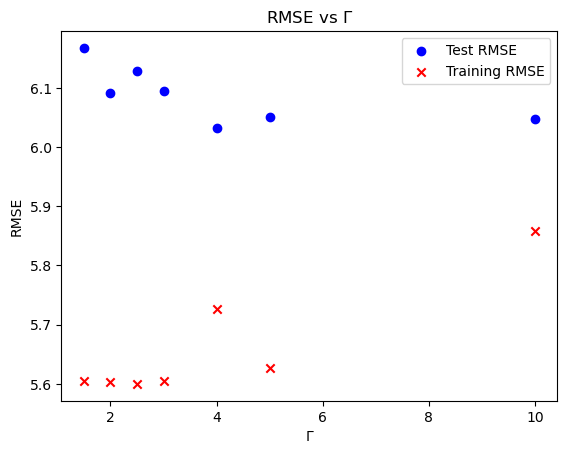

In [242]:
plt.scatter(gamma_values, test_rmse, color='blue', marker='o', label='Test RMSE')
plt.scatter(gamma_values, rmse, color='red', marker='x', label='Training RMSE') 
plt.xlabel("$\Gamma$")
plt.ylabel("RMSE")
plt.title("RMSE vs $\Gamma$")
plt.legend()
plt.show()

In [294]:
# evaluate nn model
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_predictions = model(X_test).squeeze()
    test_loss = criterion(test_predictions, y_test)
    y_pred = test_predictions.cpu().numpy()
    print("Mean actual BMI: ", np.mean(y_test.cpu().numpy()))
    print("Mean predicted BMI: ", np.mean(y_pred))
    print("RMSE: ", np.sqrt(test_loss.item()))

Mean actual BMI:  29.303
Mean predicted BMI:  28.836178
RMSE:  6.611820859592742


c:\Users\frank\anaconda3\envs\deep_learning\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([5169, 1])) that is different to the input size (torch.Size([5169])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [296]:
# evaluate linear model
y_pred = linear_model.predict(X_test.cpu().numpy())
print("Mean actual BMI: ", np.mean(y_test.cpu().numpy()))
print("Mean predicted BMI: ", np.mean(y_pred))
print("RMSE: ", np.sqrt(test_loss.item()))

Mean actual BMI:  29.303
Mean predicted BMI:  28.551025
RMSE:  6.611820859592742


#### Adjust Covariate shift 

In [297]:

from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

# Step 1: Combine datasets and create labels
X_combined = np.vstack([X_train.to(device).cpu().numpy(), X_test.to(device).cpu().numpy()])
z_train = -1 * np.ones(X_train.shape[0])  # Labels for q(x)
z_test = 1 * np.ones(X_test.shape[0])  # Labels for p(x)
z_combined = np.concatenate([z_train, z_test])

# # Step 2: Normalize the features (optional but helpful for logistic regression)
# scaler = MinMaxScaler()
# X_combined = scaler.fit_transform(X_combined)

# Step 3: Shuffle the data for better training
X_combined, z_combined = shuffle(X_combined, z_combined, random_state=42)

# Step 4: Train a logistic regression classifier
clf = LogisticRegression()
clf.fit(X_combined, z_combined)

# Step 5: Compute the density ratio for each sample in the training set
# Logistic regression predicts probabilities: P(z = 1 | X)
prob_test = clf.predict_proba(X_train)[:, 1]  # Probability of z = 1 (test distribution)
density_ratio = prob_test / (1 - prob_test)  # Compute density ratio w(x) = p(x) / q(x)

# Display some results
print("Example density ratios for training samples:")
print(density_ratio[:10])

Example density ratios for training samples:
[0.03770872 0.01201518 0.04342492 0.06091598 0.05282131 0.04173469
 0.06646735 0.01668329 0.00653981 0.04665171]


In [298]:
weights = torch.tensor(density_ratio, dtype=torch.float32)

# Create a dataset and dataloader for batch training
train_dataset = TensorDataset(X_train, y_train, weights)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = neural_net(X_train.shape[1], "neural_network").to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Step 4: Training Loop with Weighted Loss
epochs = 100
loss_arr = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y, batch_weights in train_loader:
        # Move data to the appropriate device
        batch_X, batch_y, batch_weights = batch_X.to(device), batch_y.to(device), batch_weights.to(device)
        
        # Forward pass
        predictions = model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)
        
        # Apply importance weights
        weighted_loss = (batch_weights * loss).mean()

        # Backward pass and optimization
        optimizer.zero_grad()
        weighted_loss.backward()
        optimizer.step()

        # Track the loss
        running_loss += weighted_loss.item()

    loss_arr.append(running_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

Epoch 10/100, Loss: 2.1529
Epoch 20/100, Loss: 2.1297
Epoch 30/100, Loss: 2.1237
Epoch 40/100, Loss: 2.1236
Epoch 50/100, Loss: 2.1287
Epoch 60/100, Loss: 2.1305
Epoch 70/100, Loss: 2.1221
Epoch 80/100, Loss: 2.1171
Epoch 90/100, Loss: 2.1166
Epoch 100/100, Loss: 2.1171


In [299]:
# Evaluation on val data
model.eval()
with torch.no_grad():
    X_val, y_val = X_val.to(device), y_val.to(device)
    test_predictions = model(X_val).squeeze()
    test_loss = criterion(test_predictions, y_val)
    y_pred = test_predictions.cpu().numpy()
    print("Mean actual BMI: ", np.mean(y_val.cpu().numpy()))
    print("Mean predicted BMI: ", np.mean(y_pred))
    print("RMSE: ", np.sqrt(test_loss.item()))

Mean actual BMI:  28.173735
Mean predicted BMI:  28.242693
RMSE:  5.25749398296917


In [300]:
# linear model on val set 
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_val.cpu().numpy())

print(f"Mean actual BMI for validation set: {np.mean(y_val.cpu().numpy()):.4f}")
print("mean predicted BMI: ", y_pred.mean())
print(f"RMSE: {np.sqrt(np.mean((y_val.cpu().numpy() - y_pred) ** 2)):.4f}")

Mean actual BMI for validation set: 28.1737
mean predicted BMI:  28.182255
RMSE: 5.2545


In [301]:
# nn model on test set 
model.eval()
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_predictions = model(X_test).squeeze()
    test_loss = criterion(test_predictions, y_test)
    y_pred = test_predictions.cpu().numpy()
    print("Mean actual BMI: ", np.mean(y_test.cpu().numpy()))
    print("Mean predicted BMI: ", np.mean(y_pred))
    print("RMSE: ", np.sqrt(test_loss.item()))

Mean actual BMI:  29.303
Mean predicted BMI:  28.668034
RMSE:  6.5324028494348605


c:\Users\frank\anaconda3\envs\deep_learning\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([5169, 1])) that is different to the input size (torch.Size([5169])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [302]:
# linear model on test set
y_pred = linear_model.predict(X_test.cpu().numpy())
print("Mean actual BMI: ", np.mean(y_test.cpu().numpy()))
print("Mean predicted BMI: ", np.mean(y_pred))
print("RMSE: ", np.sqrt(np.mean((y_test.cpu().numpy() - y_pred) ** 2)))

Mean actual BMI:  29.303
Mean predicted BMI:  28.551025
RMSE:  6.3796344
